# NGC 4151 spectral fit with the complete DC4 catalog

This notebook fits the existing NGC 4151 GTI-cut mock data with all
71 simulation-file entries (52 point sources and 19 extended sources) from
`Source_catalog_generator_all_DC4_fit_norm.ipynb`.

Use `source_catalog_DC4_all_71files_NGC4151_GTI_fit_norm.yaml` because the
data have the NGC 4151 pointing/occultation cut. Here “complete catalog” means
all source entries, **not** the separately saved full-time normalization YAML.
The latter does not match these GTI-calibrated variable-source amplitudes.

All 70 nuisance sources remain fixed. Only the NGC 4151 cutoff-power-law normalization, index, and cutoff energy
and the instrumental-background rate are fitted. The point-source response
and cached extended response both use the ordinary NGC 4151 GTI history;
no light curve is applied again. The fitted transient amplitudes are effective
GTI averages, not instantaneous fluxes or exact time-dependent templates.

This notebook does not rewrite the catalog, regenerate the cached response,
or add source counts to the instrumental-background template.

In [1]:
from pathlib import Path
import sys

import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from astromodels import (
    Cutoff_powerlaw, ExtendedSource, PointSource, Parameter, Powerlaw, load_model,
)
from histpy import Histogram
from threeML import DataList, JointLikelihood

from cosipy import BinnedData
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.data_io import EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import (
    BinnedInstrumentResponse,
    BinnedThreeMLModelFolding,
    BinnedThreeMLPointSourceResponse,
    BinnedThreeMLExtendedSourceResponse,
    ExtendedSourceResponse,
)
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.statistics import PoissonLikelihood
from cosipy.threeml.custom_functions import GalpropHealpixModel, SpecFromDat  # noqa: F401

%matplotlib inline

18:11:00 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=462829;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=649216;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=8428;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=219457;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=514521;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=850711;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

18:11:01 INFO      Starting 3ML!                                                                     ]8;id=320321;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=724151;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=159260;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=313391;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=49732;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=917697;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=806667;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=976187;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=944074;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=32681;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=937705;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=350475;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=25241;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=399996;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## Load the FOV-cut data and response

The mock-data and background files below were binned after applying the same 60° NGC 4151 pointing cut used for the spacecraft history.

In [2]:
notebook_dir = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN"
)
dc4_root_candidates = [
    Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files"),
    Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files"),
]
dc4_files_root = next((p for p in dc4_root_candidates if p.exists()), None)
if dc4_files_root is None:
    raise FileNotFoundError(f"Cannot find DC4 data: {dc4_root_candidates}")

# Keep the existing updated-NGC4151 mock dataset and instrumental background.
mock_data_path = dc4_files_root / (
    "Mock_Data/Mock_Data_Cut/mock_with_updated_NGC4151_FluxNTH_0p30_time_cut.hdf5"
)
background_path = dc4_files_root / (
    "Background/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5"
)
orientation_path = dc4_files_root / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
response_path = dc4_files_root / (
    "ResponseContinuum.o3.e100_10000.b10log.s10396905069491."
    "m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
agn_config = notebook_dir / "agn.yaml"
source_catalog_path = notebook_dir / "source_catalog_DC4_all_71files_NGC4151_GTI_fit_norm.yaml"
extended_response_path = dc4_files_root / (
    "Extended_Responses/NGC4151_Cut/"
    "DC4_continuum_NGC4151_60deg_GTI_extended_response_nside8.h5"
)

# Scale counts and both response exposures, never the catalog flux parameters.
# Eight repetitions represent 24 months; they are not a new Poisson realization.
exposure_multiplier = 1
exposure_months = 3 * exposure_multiplier
if not np.isfinite(exposure_multiplier) or exposure_multiplier <= 0:
    raise ValueError("exposure_multiplier must be finite and positive")

for path in (mock_data_path, background_path, orientation_path, response_path,
             agn_config, source_catalog_path, extended_response_path):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing input: {path}. Generate the GTI catalog and extended "
            "response with Source_catalog_generator_all_DC4_fit_norm.ipynb first."
        )

model = load_model(source_catalog_path)
if len(model.sources) != 71 or "ngc4151" not in model.point_sources:
    raise RuntimeError("Expected the complete 71-entry catalog including ngc4151")
if model.free_parameters:
    raise RuntimeError("The input catalog must have all parameters fixed")
print("Catalog:", source_catalog_path.name)
print(f"Sources: {len(model.point_sources)} point + {len(model.extended_sources)} extended")
print("Extended response:", extended_response_path)

Catalog: source_catalog_DC4_all_71files_NGC4151_GTI_fit_norm.yaml
Sources: 52 point + 19 extended
Extended response: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/Extended_Responses/NGC4151_Cut/DC4_continuum_NGC4151_60deg_GTI_extended_response_nside8.h5


Apply the same 60° pointing cut and Earth-occultation selection as the
catalog generator, using its exact NGC 4151 coordinates. Every source uses
this ordinary GTI history. The fitted catalog amplitudes already account for
the variable sources' effective contribution during this GTI.

In [3]:
source_l = model.ngc4151.position.l.value * u.deg
source_b = model.ngc4151.position.b.value * u.deg
source_coord = SkyCoord(l=source_l, b=source_b, frame="galactic")

max_offaxis = 60 * u.deg
earth_occ = True

sc_orientation_full = SpacecraftHistory.open(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    sc_orientation_full,
    max_offaxis,
    earth_occ=earth_occ,
)
sc_orientation_cut = sc_orientation_full.apply_gti(source_gti)

# Repeat the selected pointing history by scaling its interval livetimes.
# The attitude and Earth-occultation selection remain unchanged.
sc_orientation = SpacecraftHistory(
    sc_orientation_cut.obstime,
    sc_orientation_cut.attitude,
    sc_orientation_cut.location,
    livetime=sc_orientation_cut.livetime * exposure_multiplier,
)
sc_orientation.cache_earth_occ = sc_orientation_cut.cache_earth_occ


full_livetime = sc_orientation_full.cumulative_livetime().to_value(u.s)
fov_livetime = sc_orientation_cut.cumulative_livetime().to_value(u.s)
scaled_livetime = sc_orientation.cumulative_livetime().to_value(u.s)
print(f"Full orientation livetime: {full_livetime:,.1f} s")
print(f"Three-month GTI livetime: {fov_livetime:,.1f} s")
print(f"Scaled {exposure_months}-month livetime: {scaled_livetime:,.1f} s")

Full orientation livetime: 6,579,555.0 s
Three-month GTI livetime: 980,415.0 s
Scaled 3-month livetime: 980,415.0 s


Load the binned mock data and matching total-background template. `exposure_multiplier` scales the three-month source and background counts to 24 months. It does not change any intrinsic source-spectrum parameters.

In [4]:
mock_data = BinnedData(agn_config)
mock_data.load_binned_data_from_hdf5(binned_data=mock_data_path)

data_hist = mock_data.binned_data.project("Em", "Phi", "PsiChi")
data_hist *= exposure_multiplier

total_bkg = Histogram.open(background_path).project("Em", "Phi", "PsiChi")
if total_bkg.axes != data_hist.axes:
    raise ValueError("Mock data and background must have identical Em/Phi/PsiChi axes")
total_bkg *= exposure_multiplier
total_bkg += sys.float_info.min
bkg_dist = {"total_bkg": total_bkg}
# FreeNormBinnedBackground takes a rate in Hz, not a dimensionless multiplier.
background_rate_initial = float(total_bkg.to_dense(copy=False).contents.sum()) / scaled_livetime
if not np.isfinite(background_rate_initial) or background_rate_initial <= 0:
    raise ValueError("Invalid initial instrumental-background rate")
print(f"Initial instrumental-background rate: {background_rate_initial:.6g} Hz")

Initial instrumental-background rate: 25.5719 Hz


Open the continuum response.

In [5]:
dr = FullDetectorResponse.open(str(response_path))

## Perform the spectral fit

Construct a mixed response: a direction-specific point-source response
for each point source, and the cached NSIDE-8 extended-source response for
extended/diffuse components. The cached response is for the **three-month
NGC 4151 GTI**; scale it in memory by `exposure_multiplier`, just as the
point-response livetimes and data counts are scaled. Its file is not rewritten.
Loading it requires approximately 13 GiB of memory.

Match the catalog generator's unpolarized folding approximation for every
component (including Crab and polarized transients). Only the in-memory
model is changed; the YAML retains its polarization information.

In [6]:
# Match the unpolarized approximation used to calibrate these amplitudes.
unpolarized_components = []
for source in model.sources.values():
    for component in source.components.values():
        degree = getattr(component.polarization, "degree", None)
        if degree is not None and degree.value != 0.0:
            degree.value = 0.0
            unpolarized_components.append(f"{source.name}.{component.name}")
print("Using unpolarized folding for:", unpolarized_components)

data = EmCDSBinnedData(data_hist)
bkg = FreeNormBinnedBackground(bkg_dist, sc_history=sc_orientation, copy=False)
instrument_response = BinnedInstrumentResponse(dr, data)
psr = BinnedThreeMLPointSourceResponse(
    data=data,
    instrument_response=instrument_response,
    sc_history=sc_orientation,
    energy_axis=dr.axes["Ei"],
    polarization_axis=dr.axes["Pol"] if "Pol" in dr.axes.labels else None,
    nside=2 * data.axes["PsiChi"].nside,
)

# Drop references to the previous response if this setup cell is rerun.
for name in ("like", "plugins", "cosi", "like_fun", "response", "esr", "extended_response"):
    globals().pop(name, None)
print("Loading cached GTI extended response (about 13 GiB)...")
extended_response = ExtendedSourceResponse.open(extended_response_path)
if extended_response.axes["NuLambda"].nside != 8:
    raise ValueError("Expected the catalog generator's NSIDE-8 extended response")
if extended_response.axes[2:] != data.axes:
    raise ValueError("Extended response and data Em/Phi/PsiChi axes do not match")
if extended_response.axes["Ei"] != dr.axes["Ei"]:
    raise ValueError("Point and extended responses have different incident-energy bins")
extended_response *= exposure_multiplier
esr = BinnedThreeMLExtendedSourceResponse(
    data=data,
    precomputed_psr=extended_response,
)
response = BinnedThreeMLModelFolding(
    data=data,
    point_source_response=psr,
    extended_source_response=esr,
)
like_fun = PoissonLikelihood(data, response, bkg)
cosi = ThreeMLPluginInterface("cosi", like_fun, response, bkg)
cosi.bkg_parameter["total_bkg"] = Parameter(
    "total_bkg",
    background_rate_initial,
    min_value=0.0,
    max_value=50.0,
    delta=max(0.05 * background_rate_initial, 1e-6),
    unit=u.Hz,
)
print(f"Mixed response ready for all {len(model.sources)} catalog sources.")
print("No light-curve weighting or source contribution in the background template.")

Using unpolarized folding for: ['crab.nebula', 'crab.peak1', 'crab.bridge', 'crab.peak2', 'grb_bn090424592.bn090424592', 'grb_bn100612726.bn100612726', 'grb_bn110605183.bn110605183', 'grb_bn131122490.bn131122490', 'grb_bn140329295.bn140329295', 'grb_bn161004964.bn161004964', 'grb_bn170405777.bn170405777', 'grb_bn180504136.bn180504136', 'grb_bn180703876.bn180703876', 'grb_bn080802386_flux150.bn080802386', 'mgf_051103.mgf051103', 'mgf_070201.mgf070201', 'mgf_070222.mgf070222', 'mgf_180128a.mgf180128a', 'mgf_200415a.mgf200415a', 'mgf_231115a.mgf231115a']
Loading cached GTI extended response (about 13 GiB)...
Mixed response ready for all 71 catalog sources.
No light-curve weighting or source contribution in the background template.


Replace only NGC 4151's in-memory catalog spectrum with a cutoff power
law. Fit its normalization `K`, photon index `index`, and cutoff energy `xc`.
The pivot remains fixed at 200 keV: freeing it together with `K` would create
a redundant normalization parameter. The source position and all 70 nuisance
sources remain fixed, and the YAML is not overwritten.

The injected reference remains the original CPL + PL used to generate the
mock data. Thus the comparison plot shows a **CPL-only fit** against the
**injected total (CPL + PL)**, not a changed simulation.

In [7]:
D = 0.30

# Injected spectrum used only for comparison in the plot.
spectrum_inj_cpl = Cutoff_powerlaw()
spectrum_inj_cpl.K.value = 0.15
spectrum_inj_cpl.piv.value = 1.0
spectrum_inj_cpl.xc.value = 200.0
spectrum_inj_cpl.index.value = -1.75
spectrum_inj_cpl.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_cpl.piv.unit = u.keV
spectrum_inj_cpl.xc.unit = u.keV

spectrum_inj_tail = Powerlaw()
spectrum_inj_tail.K.value = (
    D * spectrum_inj_cpl.evaluate_at(200.0)
)
spectrum_inj_tail.piv.value = 200.0
spectrum_inj_tail.index.value = -3.8
spectrum_inj_tail.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_tail.piv.unit = u.keV
spectrum_inj = spectrum_inj_cpl + spectrum_inj_tail

# Replace NGC 4151 only; initialize from the catalog's thermal component.
assert len(model.free_parameters) == 0
catalog_source = model.ngc4151
catalog_shape = catalog_source.spectrum.main.composite
spectrum_cpl = Cutoff_powerlaw(
    K=catalog_shape.K_1.value,
    piv=catalog_shape.piv_1.value,
    index=catalog_shape.index_1.value,
    xc=catalog_shape.xc_1.value,
)
ngc4151_cpl_source = PointSource(
    "ngc4151",
    l=catalog_source.position.l.value,
    b=catalog_source.position.b.value,
    spectral_shape=spectrum_cpl,
)
for parameter in ngc4151_cpl_source.parameters.values():
    parameter.fix = True
model.remove_source("ngc4151")
model.add_source(ngc4151_cpl_source)
ngc4151_fit = model.ngc4151.spectrum.main.Cutoff_powerlaw

ngc4151_fit.K.min_value = 1e-8
ngc4151_fit.K.max_value = 1e-2
ngc4151_fit.K.delta = 0.1 * ngc4151_fit.K.value
ngc4151_fit.K.fix = False

ngc4151_fit.index.min_value = -10.0
ngc4151_fit.index.max_value = 10.0
ngc4151_fit.index.delta = 0.1
ngc4151_fit.index.fix = False

ngc4151_fit.xc.min_value = 100.0
ngc4151_fit.xc.max_value = 10000.0
ngc4151_fit.xc.delta = 0.1 * ngc4151_fit.xc.value
ngc4151_fit.xc.fix = False
ngc4151_fit.piv.fix = True

expected_free_parameters = {
    "ngc4151.spectrum.main.Cutoff_powerlaw.K",
    "ngc4151.spectrum.main.Cutoff_powerlaw.index",
    "ngc4151.spectrum.main.Cutoff_powerlaw.xc",
}
assert set(model.free_parameters) == expected_free_parameters
assert len(model.sources) == 71
print("NGC 4151 fit model: cutoff power law only")
print("Free parameters:", list(model.free_parameters))

NGC 4151 fit model: cutoff power law only
Free parameters: ['ngc4151.spectrum.main.Cutoff_powerlaw.K', 'ngc4151.spectrum.main.Cutoff_powerlaw.index', 'ngc4151.spectrum.main.Cutoff_powerlaw.xc']


Fit the source model and background normalization once.

In [8]:
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose=False)
_ = like.fit()

18:11:31 INFO      set the minimizer to minuit                                             ]8;id=702743;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=54234;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

18:19:17 WARNING   15.299999999999999 percent of samples have been thrown away because     ]8;id=652645;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=50280;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  they failed the constraints on the parameters. This results might not be                         
                  suitable for error propagation. Enlarge the boundaries until you loose                           
                  less than 1 percent of the samples.                                                              

18:19:17 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=837645;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=242024;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=148381;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=793059;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

Best fit values:

...

1.00,0.96,-0.99,0.23
0.96,1.00,-0.98,0.28
-0.99,-0.98,1.00,-0.31
0.23,0.28,-0.31,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-118228894.8539544
total,-118228894.8539544


Values of statistical measures:

,statistical measures
AIC,-236457781.70773518
BIC,-236457740.31761998


## Error propagation and plotting

Propagate the fitted parameter uncertainties to the NGC 4151 spectrum.

In [9]:
results = like.results
print(results.display())

optimized_model = results.optimized_model
fitted_shape = optimized_model.ngc4151.spectrum.main.Cutoff_powerlaw

# Propagate all three correlated CPL parameters without mutating the fit model.
def ngc4151_flux(e, K, index, xc):
    return K * (e / fitted_shape.piv.value)**index * np.exp(-e / xc)

results_err = results.propagate(
    ngc4151_flux,
    K=results.get_variates(fitted_shape.K.path),
    index=results.get_variates(fitted_shape.index.path),
    xc=results.get_variates(fitted_shape.xc.path),
)
print(optimized_model.ngc4151)

Best fit values:

,result,unit
parameter,,
ngc4151.spectrum.main.Cutoff_powerlaw.K,(1.7 -0.8 +1.6) x 10^-5,1 / (keV s cm2)
ngc4151.spectrum.main.Cutoff_powerlaw.index,-1.0 +/- 0.8,
ngc4151.spectrum.main.Cutoff_powerlaw.xc,(1.7 -0.7 +1.2) x 10^2,keV
total_bkg,(2.5587 +/- 0.0007) x 10,Hz


Correlation matrix:

1.00,0.96,-0.99,0.23
0.96,1.00,-0.98,0.28
-0.99,-0.98,1.00,-0.31
0.23,0.28,-0.31,1.00


Values of -log(likelihood) at the minimum:

...

,statistical measures
AIC,-236457781.70773518
BIC,-236457740.31761998


None


18:19:18 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=341212;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=33742;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=868022;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=343248;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

  * ngc4151 (point source):
    * position:
      * l:
        * value: 155.077404
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06317
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 1.7118457900054236e-05
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-08
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 200.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -1.0416688529

Evaluate the fitted and injected spectra from 200 keV to 5 MeV.

In [10]:
energy = np.geomspace(200 * u.keV, 5 * u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)

binned_energy_edges = data_hist.axes["Em"].edges.to_value(u.keV)
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])
expectation = response.expectation()

Plot the fitted and injected SED using the same style as `AGN_Corona_DC4_SubMethod.ipynb`.

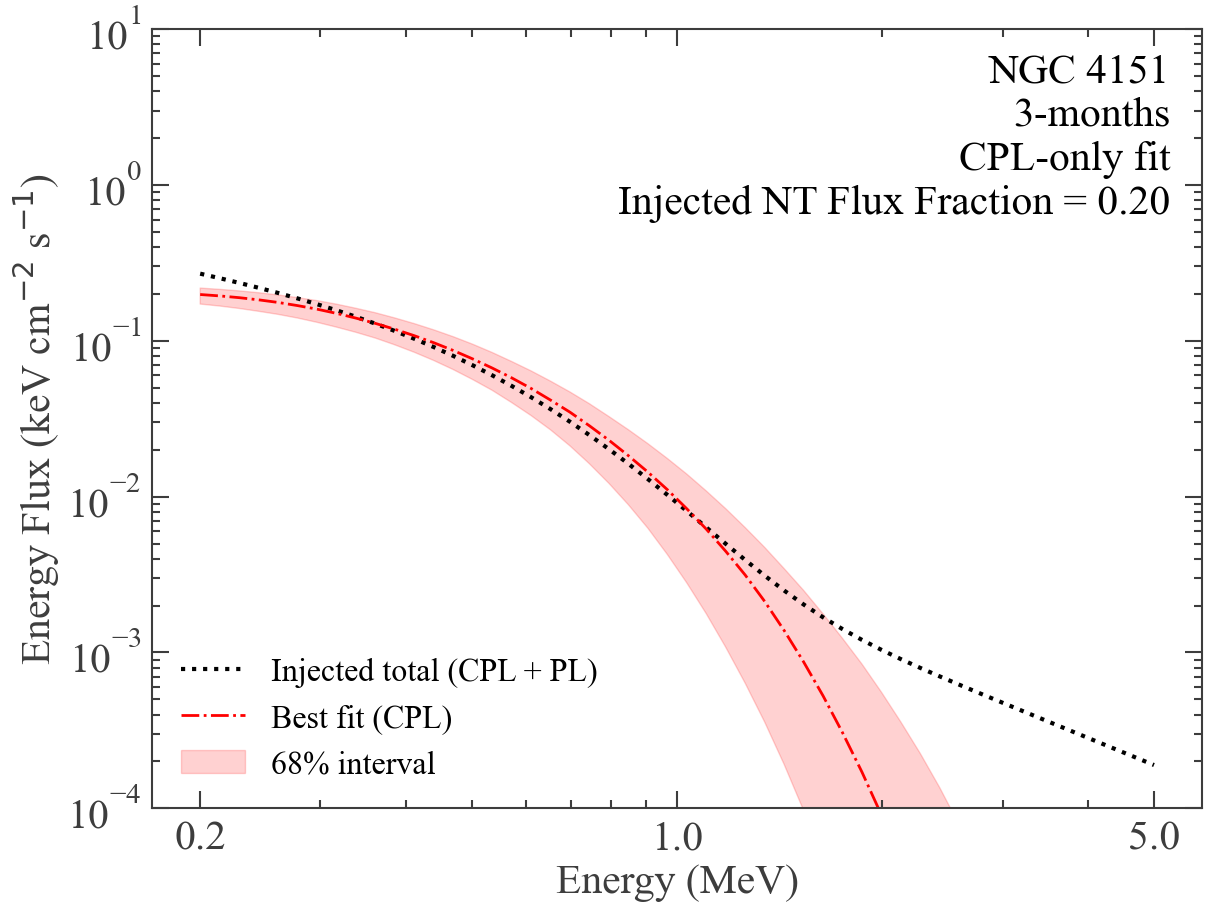

In [11]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.plot(
    energy / 1000,
    energy * energy * flux_inj,
    color="black",
    ls=":",
    lw=3,
    label="Injected total (CPL + PL)",
)
ax.plot(
    energy / 1000,
    energy * energy * flux_median,
    color="red",
    lw=2,
    linestyle="dashdot",
    label="Best fit (CPL)",
)
ax.fill_between(
    energy / 1000,
    energy * energy * flux_lo,
    energy * energy * flux_hi,
    alpha=0.18,
    color="red",
    label="68% interval",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-4, 10)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

thermal_flux = np.asarray([spectrum_inj_cpl.evaluate_at(e) for e in energy])
tail_flux = np.asarray([spectrum_inj_tail.evaluate_at(e) for e in energy])
thermal_energy_flux = np.trapezoid(energy * thermal_flux, energy)
tail_energy_flux = np.trapezoid(energy * tail_flux, energy)
energy_flux_ratio = tail_energy_flux / (thermal_energy_flux + tail_energy_flux)

ax.text(
    0.97,
    0.97,
    f"NGC 4151\n{exposure_months}-months\nCPL-only fit\nInjected NT Flux Fraction = {energy_flux_ratio:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE,
    fontweight="550",
)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()

Plot the complete forward-folded 71-entry catalog plus the fitted instrumental background against the observed mock counts.

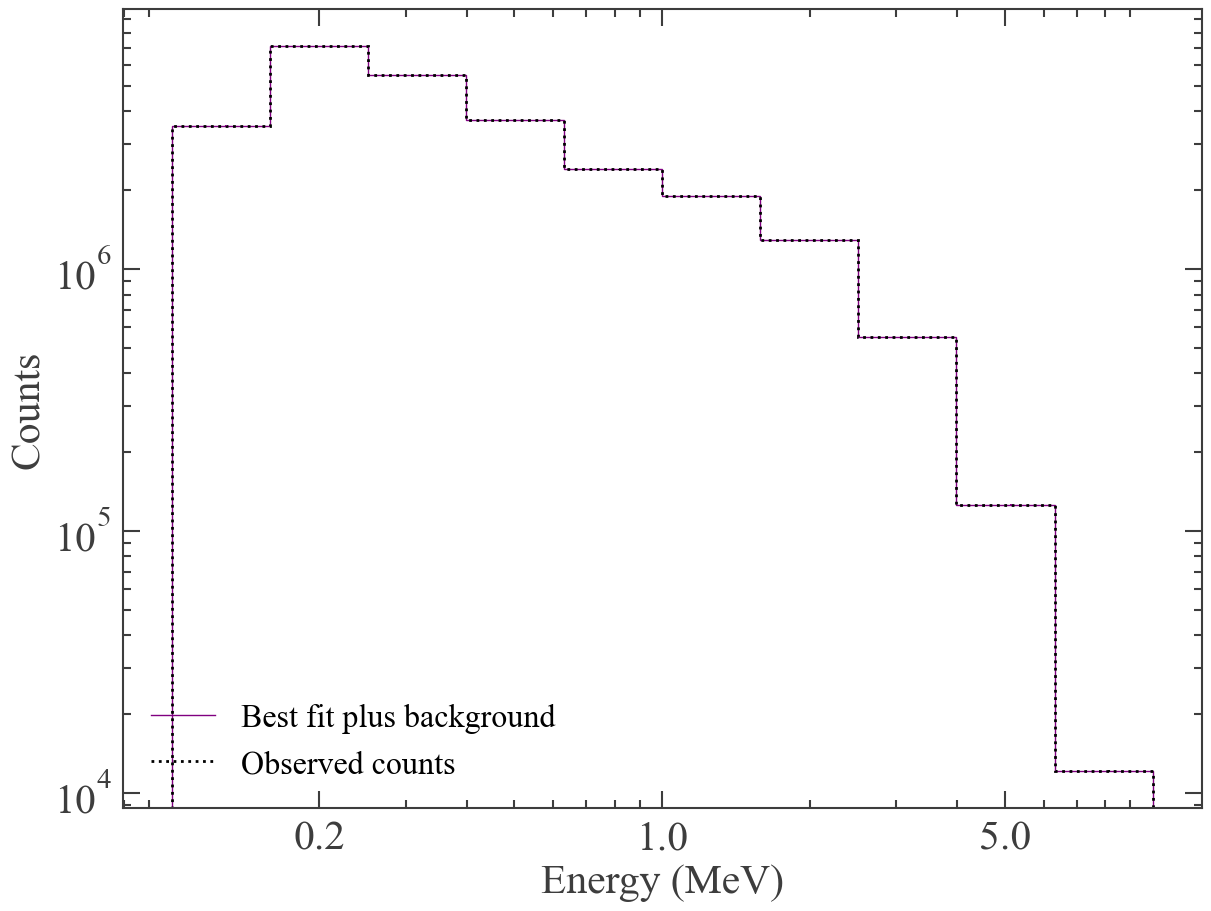

In [12]:
expectation_bkg = bkg.expectation(copy=True)
model_counts = (
    expectation.project("Em").to_dense(copy=False).contents
    + expectation_bkg.project("Em").to_dense(copy=False).contents
)
data_counts = data.data.project("Em").to_dense(copy=False).contents

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.stairs(
    model_counts,
    binned_energy_edges / 1000,
    color="purple",
    label="Best fit plus background",
)
ax.errorbar(
    binned_energy / 1000,
    model_counts,
    yerr=np.sqrt(model_counts),
    color="purple",
    linewidth=0,
    elinewidth=1.5,
)
ax.stairs(
    data_counts,
    binned_energy_edges / 1000,
    color="black",
    ls=":",
    lw=2,
    label="Observed counts",
)
ax.errorbar(
    binned_energy / 1000,
    data_counts,
    yerr=np.sqrt(data_counts),
    color="black",
    linewidth=0,
    elinewidth=1.5,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()